In [1]:
# ============================================================================
# Environment
#   Python >= 3.10. Install dependencies with:
#       pip install -r requirements.txt
#   Run this notebook from the directory that contains it -- the one holding
#   survey_data/ -- so the relative ./survey_data/ paths below resolve.
# ============================================================================

import sys, os
print("Python:", sys.version.split()[0])
print("Working directory:", os.getcwd())
assert os.path.isdir("./survey_data"), (
    "./survey_data not found. Start Jupyter from the directory that contains "
    "this notebook and survey_data/, then re-run this cell."
)


# Generated figures are written here, not to the notebook's directory.
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

import pandas as pd
df = pd.read_excel("./survey_data/survey_results/survey_results.xlsx")
df["j"] = df["j"].fillna("NA").astype(str)
df["j_2"] = df["j_2"].fillna("NA").astype(str)
# Compute change variables at participant level
df["judgment_changed"] = (df["j"] != df["j_2"]).astype(int)
df["confidence_changed"] = (df["c"] != df["c_2"]).astype(int)
df["any_change"] = ((df["j"] != df["j_2"]) | (df["c"] != df["c_2"])).astype(int)

# Capture direction of confidence change
df["confidence_increased"] = (df["c_2"] > df["c"]).astype(int)
df["confidence_decreased"] = (df["c_2"] < df["c"]).astype(int)
df["confidence_no_change"] = (df["c_2"] == df["c"]).astype(int)


Python: 3.10.13
Working directory: /Users/ziyuchen/AITA_data_profiling/controversy_certainty


# change rate

## weakening

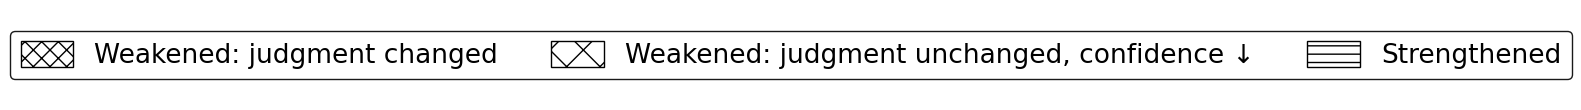

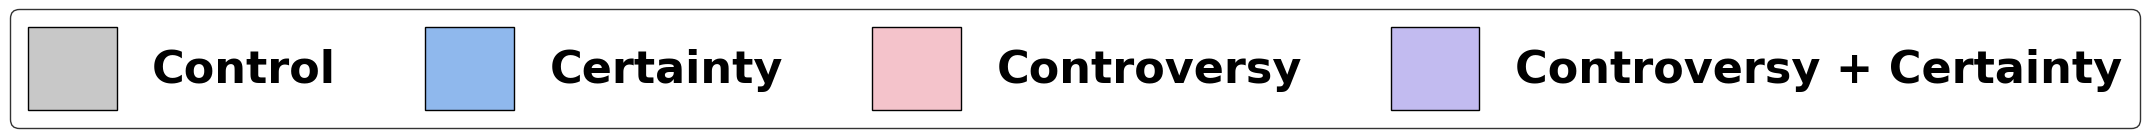

In [2]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

FS_LEG = 19

legend_patches = [
    Patch(facecolor='white', edgecolor='black', hatch='xx', label='Weakened: judgment changed'),
    Patch(facecolor='white', edgecolor='black', hatch='x',  label='Weakened: judgment unchanged, confidence \u2193'),
    Patch(facecolor='white', edgecolor='black', hatch='--', label='Strengthened'),
]

fig_leg = plt.figure(figsize=(14, 1.2))
ax_leg  = fig_leg.add_subplot(111)
ax_leg.axis('off')

leg = ax_leg.legend(
    handles=legend_patches,
    loc='center',
    handleheight=1.1,
    fontsize=FS_LEG,
    ncols=4,
    frameon=True,
    facecolor='white',
    framealpha=0.9,
    edgecolor='black',
    borderaxespad=0
)

plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Setup style variables
FONTSIZE_LEGEND = 32
pal_base = {
    "Control": "#C8C8C8",

    "Controversy": "#F4C3CB",
        "Certainty": "#8FB8ED",
    "Controversy + Certainty": "#C2BBF0"
}

# 2. Create the patches
legend_patches = [Patch(facecolor=pal_base[label], edgecolor='black', linewidth=1, label=label) 
                  for label in ["Control", "Certainty", "Controversy", "Controversy + Certainty"]]

# 3. Create a figure dedicated only to the legend
fig_leg = plt.figure(figsize=(6, 1.5)) # Increased height slightly for the larger cells
ax_leg = fig_leg.add_subplot(111)

# Add the legend with bold text and taller color cells
legend = ax_leg.legend(
    handles=legend_patches, 
    loc='center', 
    ncol=4, 
    prop={'weight': 'bold', 'size': FONTSIZE_LEGEND}, # Bolding the text
    handleheight=2.5,        # Makes the color cell taller
    handlelength=2,        # Makes the color cell wider/more square
    labelspacing=0.3,        # Adds vertical space between items (if multi-row)
    columnspacing=2,       # Adds horizontal space between columns
    frameon=True, 
    edgecolor='black', 
    framealpha=0.8
)

# 4. Hide the axes and the spine
ax_leg.axis('off')

# 5. Extract and show
fig_leg.canvas.draw()
bbox = legend.get_window_extent().transformed(fig_leg.dpi_scale_trans.inverted())

plt.show()

WEAKENING RATE SUMMARY (all values as counts and percentages)
              treatment    n  judgment_changed_n  judgment_changed_pct  unchanged_conf_down_n  unchanged_conf_down_pct  total_weakened_n  total_weakened_pct
                Control 1070                  34                   3.2                     23                      2.1                57                 5.3
            Controversy 1072                  95                   8.9                     75                      7.0               170                15.9
              Certainty 1092                  72                   6.6                     44                      4.0               116                10.6
Controversy + Certainty 1084                  56                   5.2                     75                      6.9               131                12.1

BARNARD'S EXACT TEST (each treatment vs Control), BH-corrected across comparisons
              treatment  weakened_n  total_n  control_weakened_n  cont

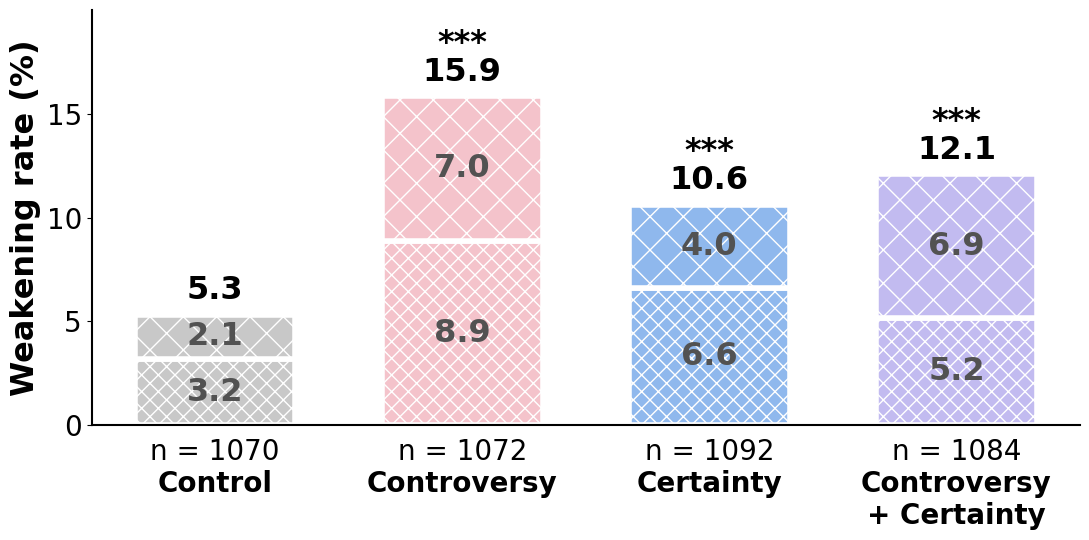

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch
from scipy.stats import barnard_exact
from scipy.stats import false_discovery_control

# =============================================================
# DATA
#
# Both inputs are derived here rather than in an earlier cell, so this
# figure stands on its own:
#   judg_data -- verdict changes per arm
#   conf_data -- confidence decreases per arm, among respondents whose
#                verdict did NOT change (the second weakening route)
# =============================================================
_jc = (df['j'] != df['j_2']).astype(int)      # matches the stored
                                              # judgment_changed column
_unchanged = df[_jc == 0].copy()
_unchanged['conf_delta'] = _unchanged['c_2'] - _unchanged['c']

judg_data, conf_data = [], []
for _t in ["control", "controversy", "certainty", "controversy_certainty"]:
    _d = df[df['treatment'] == _t]
    judg_data.append({
        'treatment': _t,
        'change': int((_d['j'] != _d['j_2']).sum()),
        'total': len(_d),
    })
    _u = _unchanged[_unchanged['treatment'] == _t]
    conf_data.append({
        'treatment': _t,
        'total': len(_u),
        'decrease': int((_u['conf_delta'] < 0).sum()),
        'increase': int((_u['conf_delta'] > 0).sum()),
    })

# new order: Control, Controversy, Certainty, Controversy + Certainty
ord_treatments = ["control", "controversy", "certainty", "controversy_certainty"]
labels_display = ["Control", "Controversy", "Certainty", "Controversy\n+ Certainty"]
labels_legend  = ["Control", "Controversy", "Certainty", "Controversy + Certainty"]

pal_base = {
    "Control":                  "#C8C8C8",
    "Certainty":                "#8FB8ED",
    "Controversy":              "#F4C3CB",
    "Controversy\n+ Certainty": "#C2BBF0"
}

# =============================================================
# RATES
# =============================================================
judg_df = pd.DataFrame(judg_data)
conf_df = pd.DataFrame(conf_data)
judg_df['p_change']    = judg_df['change']   / judg_df['total']
judg_df['p_unchanged'] = 1 - judg_df['p_change']
conf_df['p_decrease']  = conf_df['decrease'] / conf_df['total']

merged = judg_df.merge(conf_df, on='treatment', suffixes=('_j', '_c'))
merged['w1'] = merged['p_change']
merged['w2'] = merged['p_unchanged'] * merged['p_decrease']
merged['weakened'] = merged['w1'] + merged['w2']
merged['label'] = merged['treatment'].map(dict(zip(ord_treatments, labels_display)))
merged['label'] = pd.Categorical(merged['label'], categories=labels_display, ordered=True)
merged = merged.sort_values('label').reset_index(drop=True)

# =============================================================
# STATS
# =============================================================
def get_p_val(count1, total1, count0, total0):
    table = [[count1, count0], [total1 - count1, total0 - count0]]
    return barnard_exact(table, alternative='two-sided').pvalue

ctrl = merged[merged['treatment'] == 'control'].iloc[0]
p_w_raw = []
weakened_counts = []
for _, row in merged[merged['treatment'] != 'control'].iterrows():
    n, n0 = int(row['total_j']), int(ctrl['total_j'])
    count1 = int(round(row['weakened']  * n))
    count0 = int(round(ctrl['weakened'] * n0))
    weakened_counts.append((count1, n, count0, n0))
    p_w_raw.append(get_p_val(count1, n, count0, n0))
p_w_bh = false_discovery_control(p_w_raw, method='bh')

def stars(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

sig_w = [''] + [stars(p) for p in p_w_bh]

# =============================================================
# PRINTED SUMMARY: COUNTS AND TEST RESULTS
# =============================================================
print("=" * 90)
print("WEAKENING RATE SUMMARY (all values as counts and percentages)")
print("=" * 90)

summary_rows = []
for _, row in merged.iterrows():
    lbl = str(row['label']).replace('\n', ' ')
    n = int(row['total_j'])
    change_n = int(row['change'])
    w1_n = int(round(row['w1'] * n))
    w2_n = int(round(row['w2'] * n))
    weak_n = int(round(row['weakened'] * n))
    summary_rows.append({
        'treatment': lbl,
        'n': n,
        'judgment_changed_n': change_n,
        'judgment_changed_pct': round(row['w1'] * 100, 1),
        'unchanged_conf_down_n': w2_n,
        'unchanged_conf_down_pct': round(row['w2'] * 100, 1),
        'total_weakened_n': weak_n,
        'total_weakened_pct': round(row['weakened'] * 100, 1)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print()
print("=" * 90)
print("BARNARD'S EXACT TEST (each treatment vs Control), BH-corrected across comparisons")
print("=" * 90)

test_treatments = merged[merged['treatment'] != 'control']['label'].astype(str).str.replace('\n', ' ', regex=False).tolist()
test_rows = []
for lbl, (count1, n, count0, n0), p_raw, p_bh, sig in zip(test_treatments, weakened_counts, p_w_raw, p_w_bh, sig_w[1:]):
    test_rows.append({
        'treatment': lbl,
        'weakened_n': count1,
        'total_n': n,
        'control_weakened_n': count0,
        'control_total_n': n0,
        'p_raw': p_raw,
        'p_bh': p_bh,
        'sig': sig
    })

test_df = pd.DataFrame(test_rows)
print(test_df.to_string(index=False))
print()
print("sig codes: *** p<0.001, ** p<0.01, * p<0.05")
print("=" * 90)

# =============================================================
# HATCH
# =============================================================
hatch_map = {'w1': 'xx', 'w2': 'x'}

# =============================================================
# STYLE
# =============================================================
FS_DATA  = 23
FS_TICK  = 20
FS_LABEL = 23
FS_SUBDATA = 23
FS_N     = 20          # font size for sample-size text

x      = np.arange(len(labels_display))
width  = 0.65
segment_keys = ['w1', 'w2']

# =============================================================
# Y-AXIS LIMIT
# =============================================================
max_weakened = merged['weakened'].max() * 100
y_max = 18

# =============================================================
# PLOT
# =============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))

bottoms = np.zeros(len(merged))

for col in segment_keys:
    hatch = hatch_map[col]
    for i, row in merged.iterrows():
        lbl   = row['label']
        color = pal_base[lbl]
        val   = row[col] * 100

        ax.bar(x[i], val, width, bottom=bottoms[i],
               color=color, edgecolor='black', linewidth=1)
        ax.bar(x[i], val, width, bottom=bottoms[i],
               color='none', edgecolor='white', linewidth=4,
               hatch=hatch)

        if val >= 2.0:                       # in-segment label
            mid = bottoms[i] + val / 2
            ax.text(x[i], mid, f'{val:.1f}', ha='center', va='center',
                    fontsize=FS_SUBDATA, fontweight='bold', color='#525252')

    bottoms += merged[col].values * 100

# total data label above each bar, with significance stars stacked above it
top = (merged['w1'].values + merged['w2'].values) * 100
for i, (t, sl) in enumerate(zip(top, sig_w)):
    ax.text(x[i], t + 0.4, f'{t:.1f}', ha='center', va='bottom',
            fontsize=FS_DATA, fontweight='bold', color='black')
    if sl:
        # Stars sit above the number, offset in points so the gap is constant
        # regardless of the y-scale. va='baseline' because asterisks sit high in
        # the em box -- va='bottom' would leave a large empty gap beneath them.
        ax.annotate(sl, xy=(x[i], t + 0.4), xytext=(0, FS_DATA + 3),
                    textcoords='offset points', ha='center', va='baseline',
                    fontsize=FS_DATA, fontweight='bold', color='black')

# sample size below each bar
n_vals = merged['total_j'].astype(int).values
for i, n in enumerate(n_vals):
    ax.text(x[i], -0.03, f'n = {n}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=FS_N, color='black')

# =============================================================
# AXES
# =============================================================
ax.set_xticks(x)
ax.set_xticklabels(labels_display, fontsize=FS_TICK, fontweight='bold',
                   rotation=0, ha='center', rotation_mode='anchor')
ax.tick_params(axis='x', length=0, pad=32)

if y_max <= 20:
    tick_step = 5
elif y_max <= 50:
    tick_step = 10
else:
    tick_step = 20

ax.set_yticks(range(0, y_max + 1, tick_step))
ax.set_yticklabels([str(v) for v in range(0, y_max + 1, tick_step)], fontsize=FS_TICK)
ax.set_ylabel('Weakening rate (%)', fontsize=FS_LABEL, fontweight='bold')
ax.set_ylim(0, 20)
ax.set_xlim(-0.5, len(labels_display) - 0.5)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.spines['top'].set_visible(False)      # hide top border
ax.spines['right'].set_visible(False)    # hide right border

# =============================================================
# LEGEND
# =============================================================
color_patches = [
    Patch(facecolor=pal_base[k], edgecolor='black', label=lbl)
    for k, lbl in zip(labels_display, labels_legend)
]
hatch_patches = [
    Patch(facecolor='white', edgecolor='black', hatch='xx', label='judgment changed'),
    Patch(facecolor='white', edgecolor='black', hatch='x',  label='judgment unchanged, confidence \u2193'),
]
legend_patches = color_patches + hatch_patches


plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig2a_weakening_rate.png"), dpi=1000, bbox_inches='tight')
plt.show()

## strengthening

STRENGTHENING RATE SUMMARY (all values as counts and percentages)
              treatment   n  strengthened_n  strengthened_pct
                Control 463              40               8.6
            Controversy 487             126              25.9
              Certainty 461             118              25.6
Controversy + Certainty 513             107              20.9

BARNARD'S EXACT TEST (each treatment vs Control), BH-corrected across comparisons
              treatment  strengthened_n  total_n  control_strengthened_n  control_total_n        p_raw         p_bh sig
            Controversy             126      487                      40              463 2.281994e-12 6.845983e-12 ***
              Certainty             118      461                      40              463 6.864416e-12 1.029662e-11 ***
Controversy + Certainty             107      513                      40              463 9.714132e-08 9.714132e-08 ***

sig codes: *** p<0.001, ** p<0.01, * p<0.05


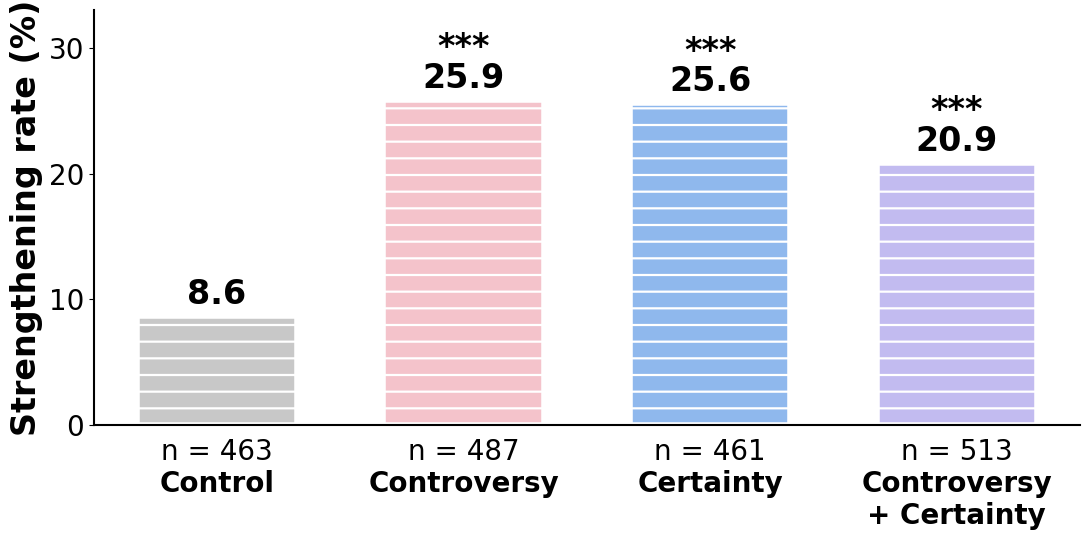

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import barnard_exact
from scipy.stats import false_discovery_control

# =============================================================
# DATA
# =============================================================
# new order: Control, Controversy, Certainty, Controversy + Certainty
ord_treatments = ["control", "controversy", "certainty", "controversy_certainty"]
labels_display = ["Control", "Controversy", "Certainty", "Controversy\n+ Certainty"]
labels_legend  = ["Control", "Controversy", "Certainty", "Controversy + Certainty"]

pal_base = {
    "Control":                  "#C8C8C8",
    "Certainty":                "#8FB8ED",
    "Controversy":              "#F4C3CB",
    "Controversy\n+ Certainty": "#C2BBF0"
}

COL_INITIAL_CONF = "c"
COL_FINAL_CONF   = "c_2"

# =============================================================
# DIRECT COUNTS - all within c < 4
# =============================================================
df_s = df[df[COL_INITIAL_CONF] < 4].copy()
df_s['judgment_changed'] = (df_s['j'] != df_s['j_2']).astype(int)

df_s['_strengthened'] = (
    (df_s['judgment_changed'] == 0) &
    (df_s[COL_FINAL_CONF] > df_s[COL_INITIAL_CONF])
).astype(int)

counts = (
    df_s.groupby('treatment')[['_strengthened']]
    .sum()
    .reset_index()
)
counts['total'] = df_s.groupby('treatment').size().reset_index(name='total')['total']

# =============================================================
# RATES
# =============================================================
merged = counts.copy()
merged['strengthened']   = merged['_strengthened'] / merged['total']
merged['n_strengthened'] = merged['_strengthened']
merged['total_j']        = merged['total']
merged['label'] = merged['treatment'].map(dict(zip(ord_treatments, labels_display)))
merged['label'] = pd.Categorical(merged['label'], categories=labels_display, ordered=True)
merged = merged.sort_values('label').reset_index(drop=True)

# =============================================================
# STATS
# =============================================================
def get_p_val(count1, total1, count0, total0):
    table = [[count1, count0], [total1 - count1, total0 - count0]]
    return barnard_exact(table, alternative='two-sided').pvalue

def stars(p):
    if pd.isna(p): return ''
    if p < 0.001:  return '***'
    if p < 0.01:   return '**'
    if p < 0.05:   return '*'
    return ''

ctrl_row = merged[merged['treatment'] == 'control'].iloc[0]
treatments_non_ctrl = [t for t in ord_treatments if t != 'control']

n0         = int(ctrl_row['total_j'])
ctrl_n_str = int(ctrl_row['n_strengthened'])

p_s_raw = []
test_pairs = []
for t in treatments_non_ctrl:
    row = merged[merged['treatment'] == t].iloc[0]
    n_str = int(row['n_strengthened'])
    n_tot = int(row['total_j'])
    test_pairs.append((n_str, n_tot, ctrl_n_str, n0))
    p_s_raw.append(get_p_val(n_str, n_tot, ctrl_n_str, n0))
p_s_bh = false_discovery_control(p_s_raw, method='bh')

sig_s = [''] + [stars(p) for p in p_s_bh]

# =============================================================
# PRINTED SUMMARY: COUNTS AND TEST RESULTS
# =============================================================
print("=" * 90)
print("STRENGTHENING RATE SUMMARY (all values as counts and percentages)")
print("=" * 90)

summary_rows = []
for _, row in merged.iterrows():
    lbl = str(row['label']).replace('\n', ' ')
    n = int(row['total_j'])
    n_str = int(row['n_strengthened'])
    summary_rows.append({
        'treatment': lbl,
        'n': n,
        'strengthened_n': n_str,
        'strengthened_pct': round(row['strengthened'] * 100, 1)
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

print()
print("=" * 90)
print("BARNARD'S EXACT TEST (each treatment vs Control), BH-corrected across comparisons")
print("=" * 90)

test_treatments = [
    str(merged[merged['treatment'] == t]['label'].iloc[0]).replace('\n', ' ')
    for t in treatments_non_ctrl
]
test_rows = []
for lbl, (n_str, n_tot, c_str, c_tot), p_raw, p_bh, sig in zip(
        test_treatments, test_pairs, p_s_raw, p_s_bh, sig_s[1:]):
    test_rows.append({
        'treatment': lbl,
        'strengthened_n': n_str,
        'total_n': n_tot,
        'control_strengthened_n': c_str,
        'control_total_n': c_tot,
        'p_raw': p_raw,
        'p_bh': p_bh,
        'sig': sig
    })

test_df = pd.DataFrame(test_rows)
print(test_df.to_string(index=False))
print()
print("sig codes: *** p<0.001, ** p<0.01, * p<0.05")
print("=" * 90)

# =============================================================
# STYLE - matched to weakening plot
# =============================================================
FS_DATA  = 24
FS_TICK  = 20
FS_LABEL = 24
FS_SUBDATA = 24
FS_N     = 20         # font size for sample-size text

x      = np.arange(len(labels_display))
width  = 0.65

# =============================================================
# Y-AXIS LIMIT
# =============================================================
max_strengthened = merged['strengthened'].max() * 100
y_max = 30   # leave headroom for the headline labels

# =============================================================
# PLOT
# =============================================================
fig, ax = plt.subplots(figsize=(11, 5.5))
plt.rcParams['hatch.linewidth'] = 1.6

for i, row in merged.iterrows():
    lbl   = row['label']
    color = pal_base[lbl]
    val   = row['strengthened'] * 100

    ax.bar(x[i], val, width, bottom=0,
           color=color, edgecolor='black', linewidth=1)
    ax.bar(x[i], val, width, bottom=0,
           color='none', edgecolor='white', linewidth=4, hatch='-')

# headline value + significance above each bar (mirrors weakening total)
str_totals = merged['strengthened'].values * 100
for i, (t, sl) in enumerate(zip(str_totals, sig_s)):
    ax.text(x[i], t + 0.4, f'{t:.1f}', ha='center', va='bottom',
            fontsize=FS_DATA, fontweight='bold', color='black')
    if sl:
        # Stars sit above the number, offset in points so the gap is constant
        # regardless of the y-scale. va='baseline' because asterisks sit high in
        # the em box -- va='bottom' would leave a large empty gap beneath them.
        ax.annotate(sl, xy=(x[i], t + 0.4), xytext=(0, FS_DATA + 3),
                    textcoords='offset points', ha='center', va='baseline',
                    fontsize=FS_DATA, fontweight='bold', color='black')

# sample size below the bar, above the treatment names
n_vals = merged['total_j'].astype(int).values
for i, n in enumerate(n_vals):
    ax.text(x[i], -0.03, f'n = {n}', transform=ax.get_xaxis_transform(),
            ha='center', va='top', fontsize=FS_N, color='black')

# =============================================================
# AXES
# =============================================================
ax.set_xticks(x)
ax.set_xticklabels(labels_display, fontsize=FS_TICK, fontweight='bold',
                   rotation=0, ha='center', rotation_mode='anchor')
ax.tick_params(axis='x', length=0, pad=32)

if y_max <= 20:
    tick_step = 5
elif y_max <= 50:
    tick_step = 10
else:
    tick_step = 20

ax.set_yticks(range(0, y_max + 1, tick_step))
ax.set_yticklabels([str(v) for v in range(0, y_max + 1, tick_step)], fontsize=FS_TICK)
ax.set_ylabel('Strengthening rate (%)', fontsize=FS_LABEL, fontweight='bold')
ax.set_ylim(0, y_max + 3)   # +3: room for the stars now stacked above the numbers
ax.set_xlim(-0.5, len(labels_display) - 0.5)

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
ax.spines['top'].set_visible(False)      # hide top border
ax.spines['right'].set_visible(False)    # hide right border

# =============================================================
# LEGEND
# =============================================================
color_patches = [
    Patch(facecolor=pal_base[k], edgecolor='black', label=lbl)
    for k, lbl in zip(labels_display, labels_legend)
]
hatch_patches = [
    Patch(facecolor='white', edgecolor='black', hatch='-', label='judgment unchanged, confidence \u2191'),
]
legend_patches = color_patches + hatch_patches

plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig2b_strengthening_rate.png"), dpi=1000, bbox_inches='tight')
plt.show()